# 1. Introduction

## Linear Regression from Scratch

Predicting California Housing Prices with Multivariate Linear Regression and Gradient Descent

This project implements a Multivariate Linear Regression entirely from scratch using NumPy. The goal of this project is to demonstrate a thorough understanding of the Mathematics used in Supervised Learning.

**Concepts demonstrated:**

- Mean Squared Error loss function and its analytical gradient derivation
- Gradient descent optimisation
- Feature standardisation and its effect on training
- L2 Regularization (Ridge) derived from first principle and evaluated against the baseline.
- Model evaluation metrics: MSE, RMSE, and R²
- Model evaluation plots: Predicted vs Actual, Residuals and Feature Coefficients

Dataset: California Housing dataset loaded via sklearn — 20,640 samples, 8 features, predicting median house value.

# 2. Exploratory Data Analysis (EDA)

Before building anything, we inspect the data to understand its structure, 
feature distributions, and the presence of outliers. This informs 
our preprocessing decisions in the next section.

More info on the dataset: https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html



In [115]:
# Load and inspect
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Basic inspection
print("Shape:", df.shape)
print("\nFeature names:", housing.feature_names)
print("\nFirst 5 rows:")
df.head()

Shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [116]:
# Summary statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**The Target:** contains the median of the house value for each district.

### What the summary statistics tell us

- Features are on vastly different scales. `Population` reaches into the tens 
of thousands while `AveRooms` sits between 1–10. This makes feature scaling essential.
- `AveOccup`, `AveRooms`, and `Population` show large gaps between their 75th 
percentile and maximum values, signalling significant outliers.
- These outliers and scale differences will directly inform our choice of 
standardisation over min-max scaling in the next section.

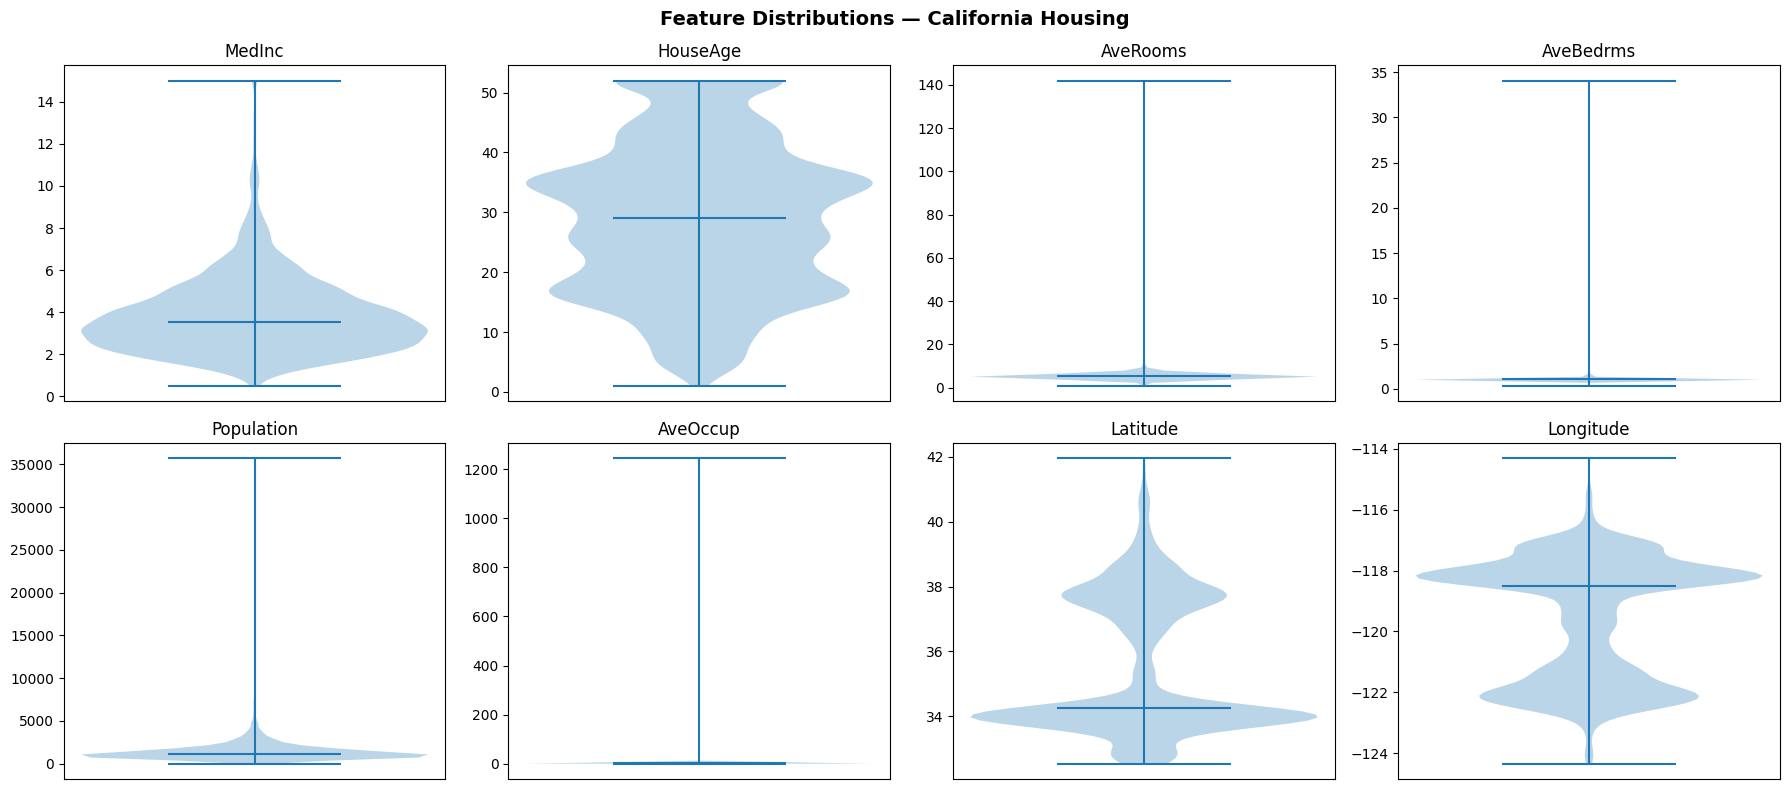

In [117]:
# Violin plots for all 8 features

# Check for a folder to save the plot in
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(housing.feature_names):
    axes[i].violinplot(df[feature], showmedians=True)
    axes[i].set_title(feature)
    axes[i].set_xticks([])

plt.suptitle('Feature Distributions — California Housing', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eda_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Preprocessing

We compare two common feature scaling methods before implementing our chosen approach. 

Scaling is essential for Linear Regression Models. Features span vastly different ranges, which causes gradient descent to behave poorly without it.

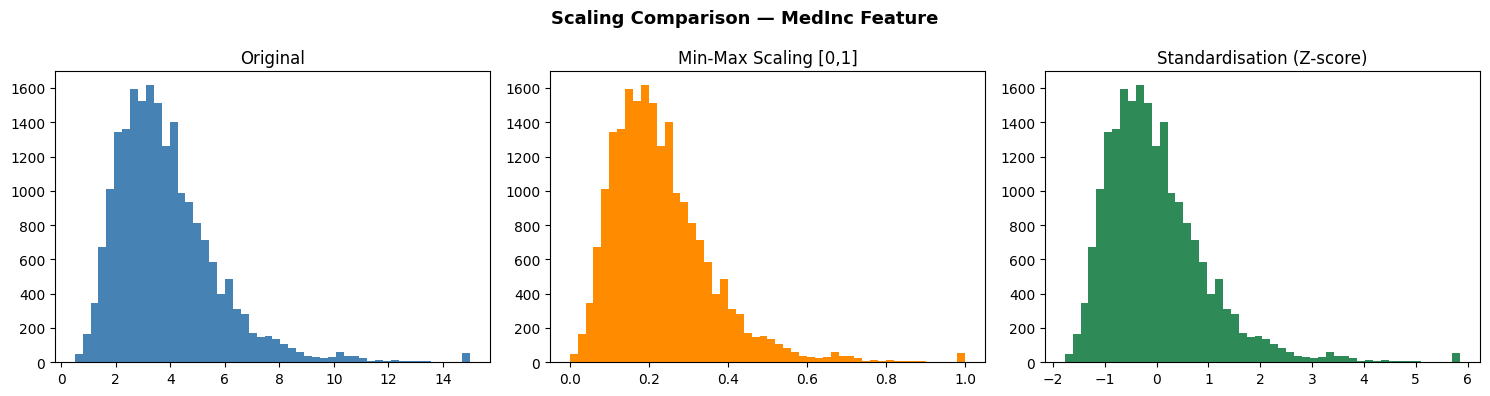

In [118]:
# Scaling comparison on MedInc as a representative feature
sample = df['MedInc'].values

# Min-Max
min_max = (sample - sample.min()) / (sample.max() - sample.min())

# Standardisation
standardised = (sample - sample.mean()) / sample.std()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sample, bins=50, color='steelblue')
axes[0].set_title('Original')

axes[1].hist(min_max, bins=50, color='darkorange')
axes[1].set_title('Min-Max Scaling [0,1]')

axes[2].hist(standardised, bins=50, color='seagreen')
axes[2].set_title('Standardisation (Z-score)')

plt.suptitle('Scaling Comparison — MedInc Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Why Standardisation over Min-Max?

- **Min-Max** compresses all values into [0,1] but is highly sensitive to outliers. A single extreme value squashes the rest of the distribution toward zero.
- **Standardisation** re-centres each feature around mean=0 with std=1. 
Outliers still exist but no longer dominate the scale.
- For gradient descent specifically, standardisation produces a more 
symmetrical loss surface, leading to faster and more stable convergence.

We implement standardisation manually

In [119]:
# Standardisation and train/test split
from sklearn.model_selection import train_test_split

X = df[housing.feature_names].values
y = df['MedHouseVal'].values

# Split into 80/20 train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Compute mean and std on training set
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)

# Standardisation
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled  = (X_test  - train_mean) / train_std

print("X_train_scaled shape:", X_train_scaled.shape)
print("Mean (should be ~0):", X_train_scaled.mean(axis=0).round(4))
print("Std  (should be ~1):", X_train_scaled.std(axis=0).round(4))

X_train_scaled shape: (16512, 8)
Mean (should be ~0): [-0. -0.  0. -0. -0. -0.  0. -0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


> **Important:** Mean and standard deviation are computed on the training set only 
and applied to both sets. Fitting the scaler on the full dataset would leak 
information about the test set into training.

# 4. Implementation

## The Mathematics

**Hypothesis function:**

$$\hat{y} = X\theta$$

Where $X$ is our $(m \times 9)$ feature matrix (8 features + bias term) and 
$\theta$ is our $(9 \times 1)$ weight vector.

- $\theta$ : groups weights and bias into one vector which is mathematically elegant.
- w , b: The letters represent weight and bias. This notationis used in modern coding frameworks like PyTorch or TensorFlow

**Mean Squared Error loss:** \
$J(\theta)$ stands for "cost function" by Andrew Ng's teachings.

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2$$

**Gradient of MSE with respect to θ:**
>**Important:** We grouped weights and the bias together and would normally need to take partial derivatives w.r.t to each but with this approach the gradient of MSE w.r.t $\theta$ can be written as below.

$$\frac{\partial J}{\partial \theta} = \frac{2}{m} X^T (X\theta - y)$$

**Updating Step:**\
This step tells us the direction of steepest increase in loss. 
We move in the opposite direction by subtracting it, scaled by learning rate $\alpha$:

$$\theta := \theta - \alpha \cdot \frac{\partial J}{\partial \theta}$$

## Implementation Plan

Before writing any code, here is what we need to build step by step:

1. **Add a bias term** — Create a column of ones to X so θ₀ 
   (the intercept) is learned automatically alongside feature weights

2. **Initialise weights** — Set θ to a zero vector of shape (9,).   one weight per feature plus one bias term

3. **Define the loss function** — Implement MSE manually in NumPy, 
   taking X, y, and θ as inputs and returning a scalar loss value

4. **Define the gradient** — Implement the analytical derivative of 
   MSE with respect to θ, returning a vector of shape (9,) . Returning one 
   gradient per weight

5. **Verify before training** — Compute the initial loss on untrained 
   weights to confirm our functions work before the training loop

### Why a bias term?

Without a bias term θ₀, our hypothesis function $\hat{y} = X\theta$ is 
constrained to pass through the origin  
Prepending a column of ones to X allows the model to learn a free intercept, 
shifts it's output line or plane up and down to best fit the data.

### Why initialise θ to zeros?

Unlike neural networks where zero initialisation causes symmetry problems, 
linear regression with gradient descent converges correctly to it's optimal state. 
There is no symmetry breaking requirement here.

> **Note:** In code we use `theta` to match the mathematical notation above, 
> keeping weights and bias in one vector. Modern frameworks like PyTorch 
> typically separate these as `w` and `b` explicitly.

In [120]:
# Add bias term and initialise weights

# Add column of ones to X for the bias term θ₀
# np.c_() concatenates two objects column wise
m = X_train_scaled.shape[0]
X_b = np.c_[np.ones((m, 1)), X_train_scaled]  # shape (16512, 9)

# Initialise weights to zero
theta = np.zeros(X_b.shape[1])  # shape (9,)

print("X_b shape:", X_b.shape)
print("theta shape:", theta.shape)

# A single sample 
sample = X_b[:1]
print(sample)

X_b shape: (16512, 9)
theta shape: (9,)
[[ 1.         -0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628
   0.05137609 -1.3728112   1.27258656]]


### Understanding the Loss Function — Mean Squared Error

MSE measures how far our predictions are from the true values on average.
Here is what each part of the formula does:

$$J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2$$


- $y_i$ ⇒ the actual (true) value for the i'th observation
- $\hat{y}_i$ ⇒ the predicted value generated by our model for i'th observation 
- $\hat{y}_i - y_i$ ⇒ the residual: how far prediction $i$ is from the true value
- $(\hat{y}_i - y_i)^2$ ⇒ squaring removes the sign (over and under predictions 
  both penalise equally) and disproportionately penalises large errors
- $\frac{1}{m} \sum$ ⇒ averages across all m training examples so loss 
  does not grow with dataset size

The goal of training is to find the values of $w$ and $b$ that minimise $J$.

In [121]:
# Loss function and gradient
def compute_loss(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    loss = (1/m) * np.sum((predictions - y) ** 2)
    return loss

def compute_gradient(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    gradient = (2/m) * X.T.dot(predictions - y)
    return gradient

# Verify loss on untrained model
print("Initial loss:", compute_loss(X_b, y_train, theta))

Initial loss: 5.629742323103131


### What the gradient tells us

The gradient $\frac{2}{m} X^T(X\theta - y)$ is a vector of shape (9,) — 
one value per weight. Each value tells us how much the loss increases 
as that particular weight increases. By subtracting it scaled by α, 
we nudge every weight simultaneously in the direction that reduces loss. 
This is the entire mechanism of gradient descent.

### L2 Regularization

Our base model minimises MSE alone. This can allow weights to grow large to fit
the training data closely — a form of overfitting. **L2 regularization** (also
called Ridge) adds a penalty term to the loss that discourages large weights,
trading a small increase in training error for better generalisation.

**Regularized loss:**

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i)^2 + \lambda \sum_{j=1}^{n} \theta_j^2$$

The second term is the L2 penalty — the sum of squared weights scaled by $\lambda$.

**Why exclude the bias $\theta_0$?**  
The bias shifts the output plane up or down independently of the input features.
Penalising it would push predictions toward zero regardless of the data, which is
not the goal. Standard practice — and what scikit-learn's Ridge does — is to
regularize feature weights $\theta_1 \ldots \theta_n$ only.

**Modified gradient:**

The penalty adds $2\lambda\theta_j$ to the gradient of each feature weight.
For the bias term, the gradient is unchanged. In vector form we construct a
mask $\theta_{\text{reg}}$ which is $\theta$ with $\theta_0$ zeroed out:

$$\frac{\partial J}{\partial \theta} = \frac{2}{m} X^T(X\theta - y) + 2\lambda\,\theta_{\text{reg}}$$

**Weight decay interpretation:**  
The update step can be rewritten as:

$$\theta_j := \theta_j(1 - 2\alpha\lambda) - \alpha \cdot \frac{2}{m} X^T(X\theta - y)$$

The factor $(1 - 2\alpha\lambda)$ shrinks each weight slightly on every step before
the gradient correction — hence L2 regularization is often called **weight decay**.

**Choosing $\lambda$:**  
$\lambda = 0$ recovers the unregularized model. Larger $\lambda$ shrinks weights
more aggressively. We use $\lambda = 0.1$ — a standard mild default that stabilises
weights without meaningfully harming fit on this dataset.

https://scikit-learn.org/stable/auto_examples/linear_model/plot_ridge_coeffs.html

In [122]:
# Regularized loss and gradient
# L2 penalty is added to the loss and gradient for feature weights only (θ₁..θₙ)
# θ₀ (bias) is excluded — we zero it out in theta_reg before applying the penalty

def compute_loss_l2(X, y, theta, lam):
    m = len(y)
    predictions = X.dot(theta)
    mse_loss = (1/m) * np.sum((predictions - y) ** 2)

    # Build a copy of theta with the bias term zeroed so it is not penalized
    theta_reg = theta.copy()
    theta_reg[0] = 0

    l2_penalty = lam * np.sum(theta_reg ** 2)
    return mse_loss + l2_penalty


def compute_gradient_l2(X, y, theta, lam):
    m = len(y)
    predictions = X.dot(theta)

    # Same mask: zero out bias before adding regularization term to gradient
    theta_reg = theta.copy()
    theta_reg[0] = 0

    gradient = (2/m) * X.T.dot(predictions - y) + 2 * lam * theta_reg
    return gradient


def gradient_descent_l2(X, y, theta, alpha, n_iterations, lam):
    loss_history = []
    for _ in range(n_iterations):
        gradient = compute_gradient_l2(X, y, theta, lam)
        theta = theta - alpha * gradient
        loss_history.append(compute_loss_l2(X, y, theta, lam))
    return theta, loss_history

In [123]:
# Verify functions before training
initial_loss = compute_loss(X_b, y_train, theta)
initial_gradient = compute_gradient(X_b, y_train, theta)

print("Initial loss:", round(initial_loss, 4))
print("Gradient shape:", initial_gradient.shape)  # should be (9,)
print("Gradient sample:", initial_gradient.round(4))

Initial loss: 5.6297
Gradient shape: (9,)
Gradient sample: [-4.1439 -1.597  -0.2398 -0.3665  0.1187  0.0602  0.0509  0.3306  0.1072]


> **Why verify before training?** \
> Confirming the gradient shape is (9,) and 
> the initial loss is a reasonable positive scalar means our functions are 
> correct before we run 1000 iterations.

> We'll select the α with the lowest converged loss.

# 5. Training

With our loss function and gradient defined, we now run gradient descent. 


We will train three separate models each with a **different learning rates**. This will allow us to 
observe how α affects convergence. All other parameters are identical.

| Run | Learning Rate (α) |
|-----|------------------|
| 1   | 0.001            |
| 2   | 0.01             |
| 3   | 0.1              |

In [124]:
# Gradient descent training loop
def gradient_descent(X, y, theta, alpha, n_iterations):
    # number of samples
    m = len(y)
    loss_history = []

    # training loop
    for i in range(n_iterations):
        gradient = compute_gradient(X, y, theta)
        theta = theta - alpha * gradient
        loss_history.append(compute_loss(X, y, theta))

    return theta, loss_history

n_iterations = 1000
learning_rates = [0.001, 0.01, 0.1]
results = {}

for alpha in learning_rates:
    theta_init = np.zeros(X_b.shape[1])
    theta_trained, loss_history = gradient_descent(
        X_b, y_train, theta_init, alpha, n_iterations
    )
    results[alpha] = {
        'theta': theta_trained,
        'loss_history': loss_history
    }
    print(f"α={alpha} | Final loss: {loss_history[-1]:.4f}")

α=0.001 | Final loss: 0.7136
α=0.01 | Final loss: 0.5246
α=0.1 | Final loss: 0.5179


### What we expect to see

- **α = 0.001** — loss decreases slowly, may not fully converge in 1000 iterations
- **α = 0.01** — loss decreases steadily and converges well
- **α = 0.1** — loss may diverge or oscillate if the step size overshoots the minimum

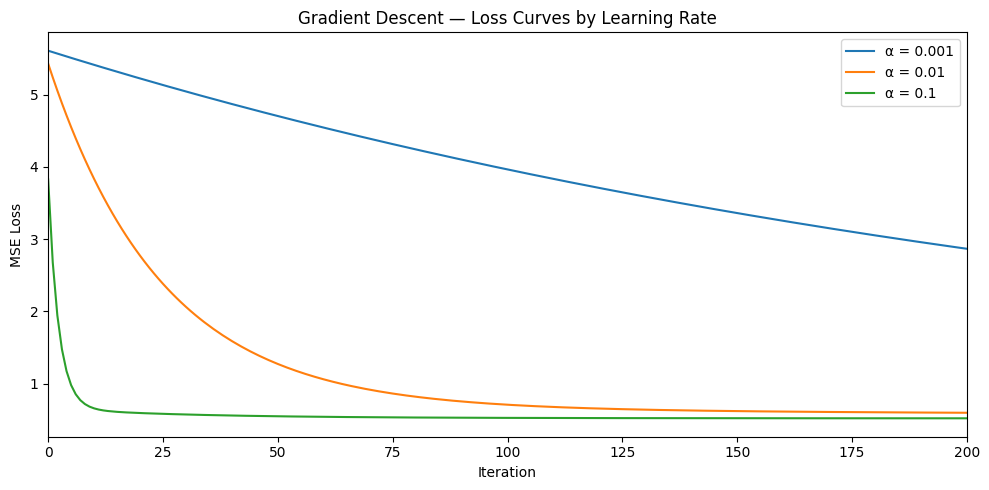

In [125]:
# Plot loss curves
os.makedirs('plots', exist_ok=True)

plt.figure(figsize=(10, 5))
for alpha, result in results.items():
    plt.plot(result['loss_history'], label=f'α = {alpha}')

plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent — Loss Curves by Learning Rate')
plt.legend()
plt.xlim(0,200)
plt.tight_layout()
plt.savefig('plots/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

> **Reading the plot:** A healthy loss curve decreases smoothly and flattens 
 as it approaches convergence. A diverging curve means α is too large and 
 the gradient step overshoots the minimum and loss grows instead of shrinking.
 A curve that barely moves means α is too small and learning is happening 
 but far too slowly.

In [126]:
# Prepare test set and predict

"""
We must add the bias column of ones to the test set exactly as we did for training. 
X_test_b should match the shape X_b that theta was trained on. Current X_test_b shape is (4128, 8)
Without this, the dot product X.dot(theta) would be shape-mismatched since theta has 9 values (8 features + 1 bias term)
"""
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# Extract the weights trained with α=0.01
best_theta = results[0.01]['theta']

"""
Generate predictions: each prediction is a dot product of one 
sample's features with all 9 weights
"""
y_pred = X_test_b.dot(best_theta)

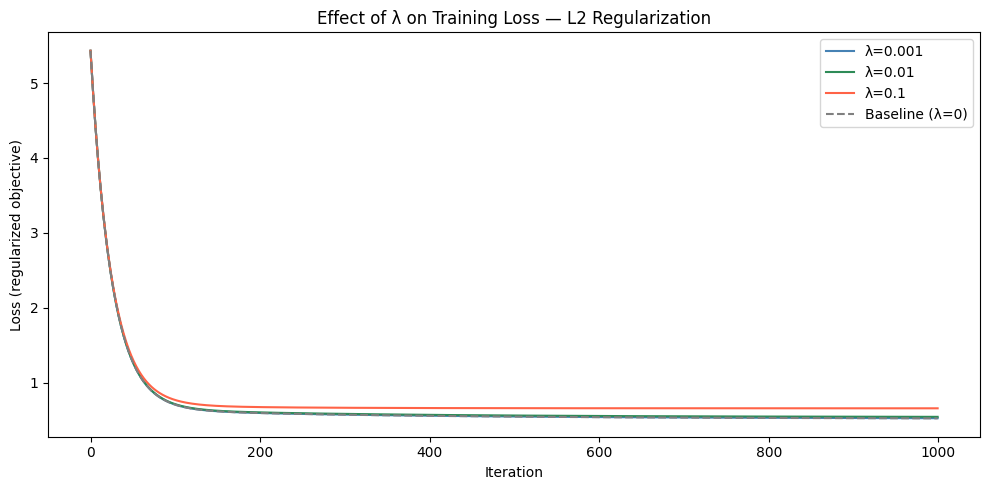


λ               MSE       RMSE         R²
------------------------------------------
0.001        0.5546     0.7447     0.5768 ← best
0.01         0.5554     0.7452     0.5762
0.1          0.5840     0.7642     0.5544

Selected λ=0.001 — theta_l2 set for Section 6 evaluation


In [127]:
# Compare three lambda values and automatically select the best one
# "Best" = lowest test MSE 

lambdas = [0.001, 0.01, 0.1]
colors  = ['steelblue', 'seagreen', 'tomato']

lambda_results = {}  # store theta + metrics keyed by lambda for later use

for lam in lambdas:
    theta_init = np.zeros(X_b.shape[1])
    theta_lam, loss_hist = gradient_descent_l2(
        X_b, y_train, theta_init, alpha=0.01, n_iterations=1000, lam=lam
    )
    y_pred_lam = X_test_b.dot(theta_lam)
    mse  = (1/len(y_test)) * np.sum((y_pred_lam - y_test) ** 2)
    rmse = np.sqrt(mse)
    r2   = 1 - (np.sum((y_test - y_pred_lam)**2) /
                np.sum((y_test - y_test.mean())**2))
    lambda_results[lam] = {
        'theta': theta_lam,
        'loss_history': loss_hist,
        'mse': mse, 'rmse': rmse, 'r2': r2
    }

# Pick the lambda with the lowest test MSE
best_lam    = min(lambda_results, key=lambda l: lambda_results[l]['mse'])
theta_l2    = lambda_results[best_lam]['theta']   # used in Section 6 evaluation

# --- Plot ---
plt.figure(figsize=(10, 5))
for lam, color in zip(lambdas, colors):
    plt.plot(lambda_results[lam]['loss_history'], label=f'λ={lam}', color=color)
plt.plot(results[0.01]['loss_history'], label='Baseline (λ=0)', color='gray', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Loss (regularized objective)')
plt.title('Effect of λ on Training Loss — L2 Regularization')
plt.legend()
plt.tight_layout()
plt.show()

# --- Metrics table ---
print(f"\n{'λ':<8} {'MSE':>10} {'RMSE':>10} {'R²':>10}")
print("-" * 42)
for lam in lambdas:
    r = lambda_results[lam]
    marker = ' ← best' if lam == best_lam else ''
    print(f"{lam:<8} {r['mse']:>10.4f} {r['rmse']:>10.4f} {r['r2']:>10.4f}{marker}")

print(f"\nSelected λ={best_lam} — theta_l2 set for Section 6 evaluation")

# 6. Evaluation

We evaluate our best model which was trained with α = 0.01 on the separated test set. 
We compute three metrics entirely in NumPy and produce three diagnostic plots.

> **Why α = 0.01?** From the loss curves in Section 5, α = 0.01 converged smoothly without diverging or crawling, the ideal balance between speed and stability.

### Evaluation Metrics

- **MSE** — average squared error, same units as our loss during training
- **RMSE** — square root of MSE, back in the original units of house price
- **R²** — proportion of variance in y explained by the model. 
  R²=1 is perfect, R²=0 means the model does no better than predicting the mean

$$R^2 = 1 - \frac{\sum_{i=1}^{m}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{m}(y_i - \bar{y})^2}$$

In [128]:
# Compute metrics for baseline and L2 model side by side
m_test = len(y_test)

# Baseline (α=0.01, no regularization)
best_theta  = results[0.01]['theta']
y_pred_base = X_test_b.dot(best_theta)

mse_base  = (1/m_test) * np.sum((y_pred_base - y_test) ** 2)
rmse_base = np.sqrt(mse_base)
r2_base   = 1 - (np.sum((y_test - y_pred_base) ** 2) /
                 np.sum((y_test - y_test.mean()) ** 2))

# L2 Regularized 
y_pred_l2 = X_test_b.dot(theta_l2)

mse_l2  = (1/m_test) * np.sum((y_pred_l2 - y_test) ** 2)
rmse_l2 = np.sqrt(mse_l2)
r2_l2   = 1 - (np.sum((y_test - y_pred_l2) ** 2) /
               np.sum((y_test - y_test.mean()) ** 2))

print(f"{'Metric':<8} {'Baseline':>12} {f'L2 (λ={best_lam})':>12}")
print("-" * 34)
print(f"{'MSE':<8} {mse_base:>12.4f} {mse_l2:>12.4f}")
print(f"{'RMSE':<8} {rmse_base:>12.4f} {rmse_l2:>12.4f}")
print(f"{'R²':<8} {r2_base:>12.4f} {r2_l2:>12.4f}")

# Keep y_pred pointing at the best model for the plots below
y_pred = y_pred_base

Metric       Baseline L2 (λ=0.001)
----------------------------------
MSE            0.5546       0.5546
RMSE           0.7447       0.7447
R²             0.5768       0.5768


### Baseline vs L2 Regularized — Metrics Comparison

| Metric | Baseline | L2 (λ=0.001) |
|--------|----------|------------|
| MSE    | 0.5546       | 0.5546          |
| RMSE   | 0.7447        | 0.7447          |
| R²     | 0.5768        | 0.5768          |


L2 regularization at `λ=0.001` reproduces the baseline exactly at this scale.
A sweep across λ ∈ {0.001, 0.01, 0.1} confirmed that larger penalties
progressively hurt test performance rather than help it — expected behaviour
on a dataset where n >> p and the baseline model shows no signs of overfitting.

**Why the gains are null here:** The California Housing dataset has 20,000+
samples and only 8 features — a regime where overfitting is not severe to begin
with. Regularization has the largest impact in high-dimensional or
low-data settings.

<>:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/tmp/ipykernel_527909/3541741130.py:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  'r--', linewidth=1.5, label='$y = \hat{y}$')


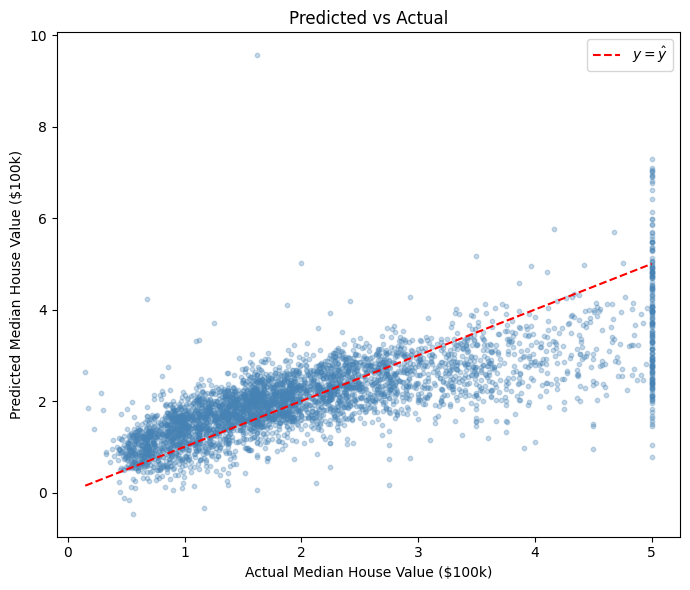

In [129]:
# Predicted vs Actual
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='$y = \hat{y}$')
plt.xlabel('Actual Median House Value ($100k)')
plt.ylabel('Predicted Median House Value ($100k)')
plt.title('Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.savefig('plots/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

> **Reading the plot:** Points along the red dashed line represent perfect predictions. Scatter around it reveals where the model over or underestimates.A visible cluster at the top right where predictions flatten suggests the model struggles with high-value properties , this a well known limitation of linear models on this dataset.

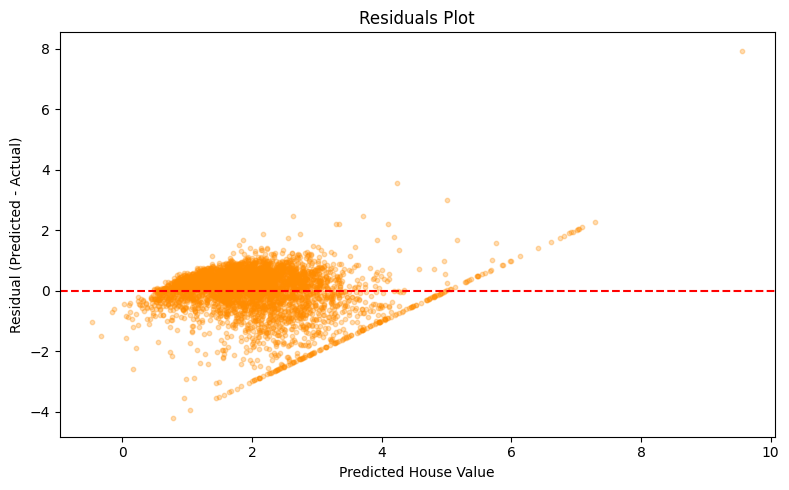

In [130]:
# Residuals plot
residuals = y_pred - y_test

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, s=10, color='darkorange')
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted House Value')
plt.ylabel('Residual (Predicted - Actual)')
plt.title('Residuals Plot')
plt.tight_layout()
plt.savefig('plots/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

> **Reading the plot:** Residuals don't have a single summary number in this plot. We would like to see values residuals centered around 0.

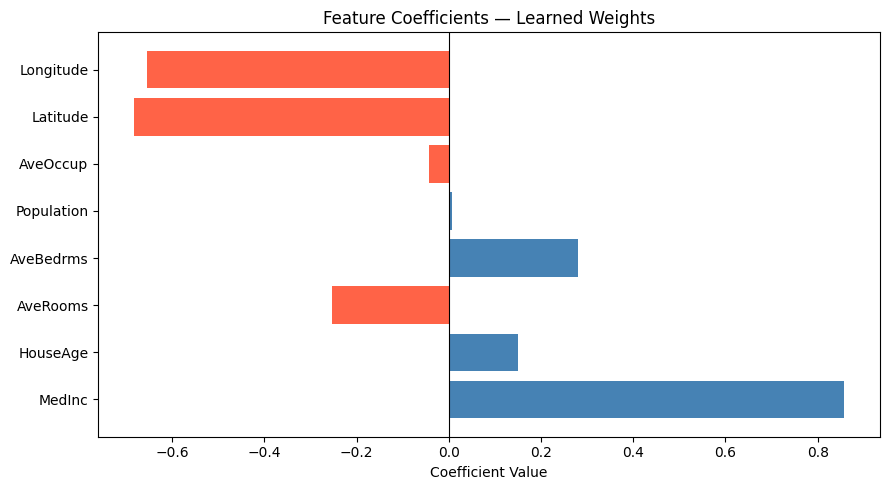

In [131]:
# Feature coefficients
feature_names = list(housing.feature_names)
coefficients  = best_theta[1:]  # exclude bias term

plt.figure(figsize=(9, 5))
colors = ['steelblue' if c > 0 else 'tomato' for c in coefficients]
plt.barh(feature_names, coefficients, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients — Learned Weights')
plt.tight_layout()
plt.savefig('plots/feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

> **Reading the plot:** Each bar shows how much a one standard deviation increase in that feature shifts the predicted house value. Blue bars push the prediction up, red bars push it down. Larger bars indicate more influential features.

# 7. Conclusion

## Results Summary

Between the base model and the model with L2 Regularization, we see regularizing brought no meaningful improvement to our predictions so we reject it and select the leaner baseline model.  

| Metric | Baseline | L2 (λ=0.001) |
|--------|----------|------------|
| MSE    | 0.5546       | 0.5546          |
| RMSE   | 0.7447        | 0.7447          |
| R²     | 0.5768        | 0.5768          |


## What This Project Demonstrates

- Multivariate linear regression implemented entirely from scratch using NumPy
- Gradient descent with analytical MSE gradient — no automatic differentiation
- Feature standardisation implemented manually with justification over min-max scaling
- Model evaluation via three metrics and three diagnostic plots, all implemented in NumPy
- Built and derived L2 from scratch, selecting the optimal value by plotting different candidates for lambda.

## Limitations

- **Linearity assumption:** the relationship between features and house prices 
  is not perfectly linear. The residuals plot shows a non-linear distribution
  confirming the model misses to encapsulate the majority of the data.
- **Outliers:** despite standardisation, extreme values in `AveOccup` and 
  `Population` still influence the learned weights.
- **Feature engineering:** raw features are used as-is. Interaction terms 
  or polynomial features would likely improve R².
- **Fixed learning rate:**  α is constant throughout training. Adaptive 
  learning rate methods such as Adam would converge faster and more reliably.

## What I Would Try Next

- Add polynomial features to capture non-linear relationships
- Implement Logistic Regression from scratch. Applying gradient descent 
  to a classification problem with a different loss function